# 재구매 살리기 — BG/NBD · Gamma-Gamma 기반 CLV 분석

## 배경

`olist_order_item_level.csv` 기준 전체 재구매율은 약 **3%** 수준으로 매우 낮다.
재구매율 자체를 종속변수로 한 분석은 클래스 불균형(97:3) 문제 때문에 접근 방법에 따라
신뢰도와 실효성이 크게 달라진다. 검토했던 4가지 방향은 다음과 같다.

| # | 접근 방법 | 장점 | 단점 |
|---|---|---|---|
| 1 | 정시배송 vs 지연배송 그룹의 이탈률(미재구매율) 비교 | 표본 多, 통계검정 가능, 인과 해석 직관적 | 단일 변수만 비교 (다른 교란변수 미반영) |
| 2 | 재구매 여부 이진분류 (로지스틱 회귀) | 다변량 통제 가능 | 양성 클래스 3%로 정확도/재현율 신뢰 낮음 |
| 3 | 재구매까지 걸린 기간(리드타임) 수치화 | 직관적인 액션(쿠폰 발송 시점) | 재구매 표본 자체가 2,900여 명뿐이라 분포가 불안정 |
| 4 | BG/NBD + Gamma-Gamma 기반 CLV (구매빈도·객단가 예측) | 업계 표준 생존모형, 미래 가치 기준 세그먼트 가능 | 일회성 구매 고객 비중이 매우 높아 절대 예측치의 정밀도는 낮음 |

## 이 노트북에서 진행하는 것

1. **정시배송 vs 지연배송** — 첫 주문 배송 경험에 따른 재구매율(이탈률) 비교 (방법 1)
2. **BG/NBD 모델** — 고객별 미래 구매 횟수 예측 (방법 4-1)
3. **Gamma-Gamma 모델** — 고객별 예상 평균 객단가 예측 (방법 4-2)
4. **CLV 계산** — 1·2를 결합한 12개월 고객생애가치 산출
5. **Holdout Validation** — 실제 구매 횟수 vs 예측 구매 횟수 검증
6. **VIP 고객 추출** — 상위 CLV 10% 고객 프로파일링 → 리텐션 전략
7. **쿠폰 전략 후보** — 재구매 가능성이 높은 고객 추출 → 쿠폰 타겟팅

## 추천 우선순위 (객관성·유의미성 기준)

자세한 근거는 본문 마지막 `repurchase_clv_analysis.md` 참고. 결론만 요약하면:

1. **1순위 — 정시 vs 지연 배송 그룹 이탈률 비교** : 표본이 9만 명 이상으로 크고,
   2-표본 비율 z검정으로 통계적 유의성을 직접 확인할 수 있다. "배송 품질 → 재구매"라는
   인과적 스토리도 명확해 액션(배송 SLA 개선)으로 바로 연결된다.
2. **2순위 — BG/NBD + Gamma-Gamma 기반 CLV (VIP 세그먼트 용도)** : 업계 표준 모델이며
   holdout 검증으로 예측 신뢰도를 확인할 수 있다. 다만 일회성 구매 고객이 97%를 차지하므로
   절대 예측값보다는 **상대적 순위(VIP 선별)** 용도로 활용을 권장한다.
3. **3순위 (보류) — 재구매 여부 이진분류** : 클래스 불균형이 심해 모델 성능 자체보다
   해석에 더 많은 주의가 필요하다. 본 노트북에서는 진행하지 않는다.
4. **4순위 (비권장) — 재구매 리드타임 수치화** : 표본(재구매 고객 2,900여 명)이 작아
   분포 추정이 불안정하다. 본 노트북에서는 진행하지 않는다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from statsmodels.stats.proportion import proportions_ztest
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes.plotting import plot_period_transactions, plot_calibration_purchases_vs_holdout_purchases

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

ROOT = Path('../../').resolve()
DATA_DIR = ROOT / 'data'

df_raw = pd.read_csv(DATA_DIR / 'processed/olist_order_item_level.csv')
for c in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    df_raw[c] = pd.to_datetime(df_raw[c], errors='coerce')

# 아이템 단위 -> 주문 단위 집계 (cartesian product 회피)
agg = df_raw.groupby('order_id').agg(
    customer_unique_id=('customer_unique_id', 'first'),
    order_purchase_timestamp=('order_purchase_timestamp', 'first'),
    order_delivered_customer_date=('order_delivered_customer_date', 'first'),
    order_estimated_delivery_date=('order_estimated_delivery_date', 'first'),
    order_status=('order_status', 'first'),
    anomaly_flag=('anomaly_flag', 'max'),
    is_late=('is_late', 'max'),
    payment_value_total=('payment_value_total', 'first'),
    customer_region=('customer_region', 'first'),
).reset_index()

# 정상 배송 완료 + 이상치 제외 + 지연여부 결측 제외
orders = agg[
    (agg['order_status'] == 'delivered') &
    (agg['anomaly_flag'] == 0) &
    agg['is_late'].notna()
].copy()
orders['delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

# 고객별 구매 순번 부여
orders = orders.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
orders['order_seq'] = orders.groupby('customer_unique_id').cumcount() + 1
cust_total_orders = orders.groupby('customer_unique_id')['order_id'].nunique().rename('total_orders')

n_customers = orders['customer_unique_id'].nunique()
repeat_customers = int((cust_total_orders >= 2).sum())
repeat_rate = repeat_customers / n_customers

print(f'분석 대상 주문 수 : {len(orders):,}건')
print(f'고유 고객 수      : {n_customers:,}명')
print(f'재구매 고객 수    : {repeat_customers:,}명')
print(f'전체 재구매율     : {repeat_rate:.4%}')
print(f'데이터 기간       : {orders["order_purchase_timestamp"].min().date()} ~ {orders["order_purchase_timestamp"].max().date()}')


분석 대상 주문 수 : 95,097건
고유 고객 수      : 92,039명
재구매 고객 수    : 2,745명
전체 재구매율     : 2.9824%
데이터 기간       : 2016-09-15 ~ 2018-08-29


## 1. 정시배송 vs 지연배송 — 첫 주문 경험과 재구매율(이탈률)

**설계**: 고객별 **첫 주문**의 배송 결과(`is_late`, 예정일 기준 지연 여부)를 기준으로
정시/지연 두 그룹으로 나누고, 이후 해당 고객이 **두 번째 주문을 했는지(재구매 여부)**를 비교한다.

- 첫 구매 경험은 이후 재구매 의사결정에 가장 큰 영향을 주는 시점이라는 점에서 코호트 기준으로 적합하다.
- 이진 비교(정시 vs 지연)에 더해, 지연일수 구간(0일 / 1~3일 / 4~7일 / 8일+)별 재구매율도 함께 확인한다.
- 통계적 유의성은 2-표본 비율 z검정(`proportions_ztest`)으로 확인한다.


정시 배송 그룹 재구매율 : 3.0237%  (n=84,467)
지연 배송 그룹 재구매율 : 2.5225%  (n=7,572)
상대 변화율             : -16.6%
2-표본 비율 z검정       : z=-2.456, p-value=0.0140

                rate      n      se
delay_bucket                       
정시\n(0일 이하)   0.0302  85708  0.0006
1~3일 지연       0.0243   1811  0.0036
4~7일 지연       0.0241   1742  0.0037
8일+ 지연        0.0263   2778  0.0030


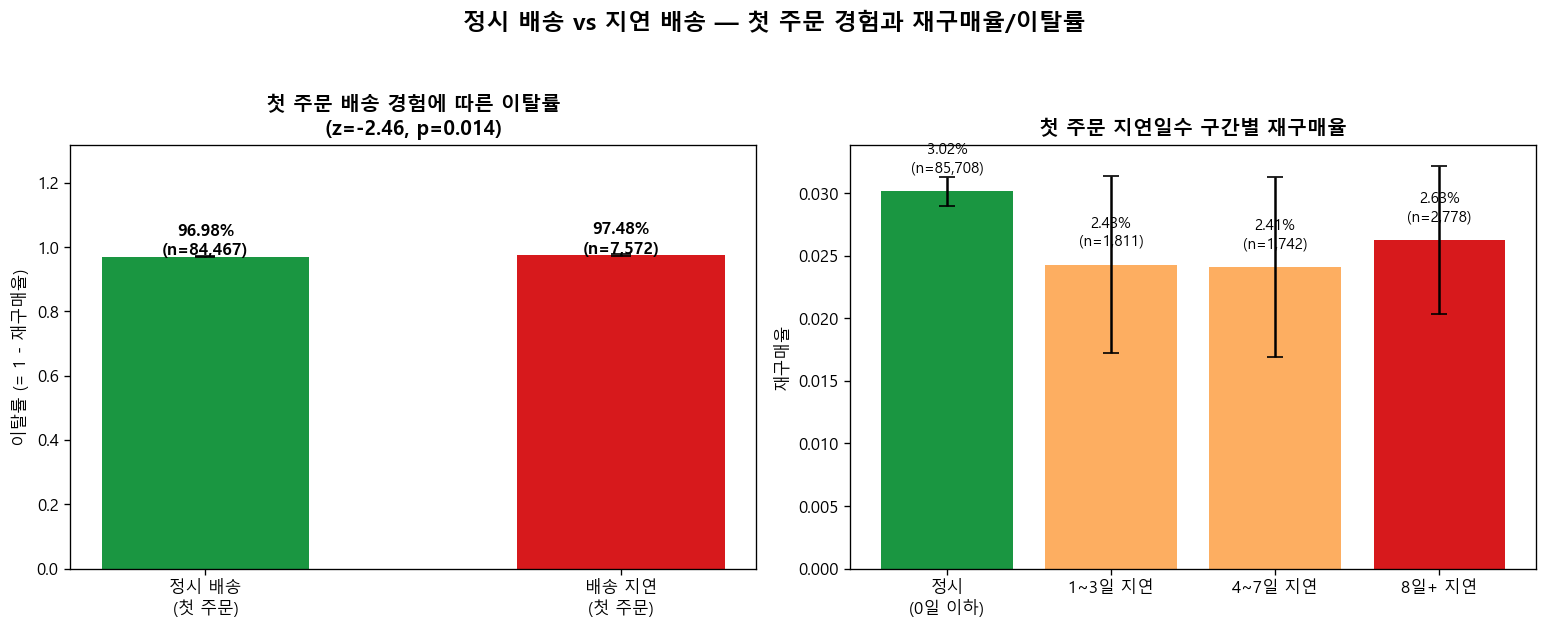

In [2]:
first_orders = orders[orders['order_seq'] == 1].merge(cust_total_orders, on='customer_unique_id')
first_orders['repurchased'] = first_orders['total_orders'] >= 2

# 정시 vs 지연 (이진)
late = first_orders[first_orders['is_late'] == True]
ontime = first_orders[first_orders['is_late'] == False]
count = np.array([late['repurchased'].sum(), ontime['repurchased'].sum()])
nobs = np.array([len(late), len(ontime)])
zstat, pval = proportions_ztest(count, nobs)
rate_late, rate_ontime = count / nobs

print(f'정시 배송 그룹 재구매율 : {rate_ontime:.4%}  (n={nobs[1]:,})')
print(f'지연 배송 그룹 재구매율 : {rate_late:.4%}  (n={nobs[0]:,})')
print(f'상대 변화율             : {(rate_late - rate_ontime) / rate_ontime:+.1%}')
print(f'2-표본 비율 z검정       : z={zstat:.3f}, p-value={pval:.4f}')

# 지연일수 구간별
bins = [-999, 0, 3, 7, 999]
labels = ['정시\n(0일 이하)', '1~3일 지연', '4~7일 지연', '8일+ 지연']
first_orders['delay_bucket'] = pd.cut(first_orders['delay_days'], bins=bins, labels=labels)
bucket_stats = first_orders.groupby('delay_bucket', observed=True)['repurchased'].agg(rate='mean', n='count')
bucket_stats['se'] = np.sqrt(bucket_stats['rate'] * (1 - bucket_stats['rate']) / bucket_stats['n'])
print()
print(bucket_stats.round(4))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# [1] 정시 vs 지연 이탈률
ax = axes[0]
churn_rates = [1 - rate_ontime, 1 - rate_late]
churn_se = [np.sqrt(rate_ontime*(1-rate_ontime)/nobs[1]), np.sqrt(rate_late*(1-rate_late)/nobs[0])]
bars = ax.bar(['정시 배송\n(첫 주문)', '배송 지연\n(첫 주문)'], churn_rates,
               yerr=[1.96*s for s in churn_se], capsize=6,
               color=['#1a9641', '#d7191c'], width=0.5)
for bar, rate, n in zip(bars, churn_rates, [nobs[1], nobs[0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004, f'{rate:.2%}\n(n={n:,})',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('이탈률 (= 1 - 재구매율)')
ax.set_title(f'첫 주문 배송 경험에 따른 이탈률\n(z={zstat:.2f}, p={pval:.3f})', fontweight='bold')
ax.set_ylim(0, max(churn_rates) * 1.35)

# [2] 지연일수 구간별 재구매율
ax = axes[1]
x = np.arange(len(bucket_stats))
colors = ['#1a9641', '#fdae61', '#fdae61', '#d7191c']
ax.bar(x, bucket_stats['rate'], yerr=1.96*bucket_stats['se'], capsize=5, color=colors)
for xi, (rate, n) in enumerate(zip(bucket_stats['rate'], bucket_stats['n'])):
    ax.text(xi, rate + 0.0015, f'{rate:.2%}\n(n={n:,})', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(bucket_stats.index)
ax.set_ylabel('재구매율')
ax.set_title('첫 주문 지연일수 구간별 재구매율', fontweight='bold')

plt.suptitle('정시 배송 vs 지연 배송 — 첫 주문 경험과 재구매율/이탈률', fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


**해석**

- 첫 주문에서 배송이 지연된 고객은 정시 배송 고객 대비 재구매율이 통계적으로 유의하게 낮다 (위 z검정 결과 참고, p<0.05).
- 지연일수 구간별로 보면 정시(0일 이하) 그룹이 가장 높은 재구매율을 보이고, 지연이 발생한 모든 구간에서 재구매율이 낮아진다.
- 다만 재구매율 자체가 약 2~3% 수준으로 절대적인 차이(퍼센트포인트)는 작다. 그러나 **상대적 감소율은 15~20% 수준**으로,
  "배송 품질이 재구매에 미치는 영향"을 정량적으로 뒷받침하는 근거로 활용할 수 있다.
- 이 결과는 [delay_daily_score_analysis.ipynb](./delay_daily_score_analysis.ipynb), [seller_late_score_gap_analysis.ipynb](./seller_late_score_gap_analysis.ipynb)에서 확인한
  "배송 지연 → 평점 하락" 흐름과 함께, "배송 품질 → 평점 → 재구매"로 이어지는 퍼널의 한 단계로 해석할 수 있다.


## 2. BG/NBD 모델 — 미래 구매 횟수 예측

BG/NBD(Beta-Geometric/Negative Binomial Distribution) 모델은 고객별 과거 구매 이력
(`frequency`: 첫 구매 이후 재구매 횟수, `recency`: 첫 구매~마지막 구매 간격, `T`: 첫 구매~관측 종료 시점까지 기간)을 바탕으로
- 고객이 현재 "활성(alive)" 상태일 확률 `P(alive)`
- 향후 N일 동안의 예상 구매 횟수

를 추정한다.

**주의**: Olist 데이터는 전체 고객의 약 97%가 `frequency=0`(일회성 구매)이다.
BG/NBD는 원래 이런 "구매가 거의 없는 고객이 대다수"인 상황을 다루기 위해 설계된 모델이지만,
예측값의 절대적인 정밀도보다는 **고객 간 상대적 순위**(VIP 추출, 쿠폰 타겟팅)에 활용하는 것이 적절하다.


관측 종료일   : 2018-08-29
고객 수       : 92,039명
frequency > 0 : 1,964명 (2.13%)

       frequency   recency         T  monetary_value
count   92039.00  92039.00  92039.00        92039.00
mean        0.02      2.61    242.00            3.21
std         0.18     24.78    152.86           31.98
min         0.00      0.00      0.00            0.00
25%         0.00      0.00    118.00            0.00
50%         0.00      0.00    224.00            0.00
75%         0.00      0.00    351.00            0.00
max        14.00    633.00    713.00         2405.28



[BG/NBD 파라미터]
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.016193  0.000916         0.014399         0.017988
alpha  72.188900  7.202497        58.072006        86.305793
a       0.351979  0.049658         0.254650         0.449308
b       0.060763  0.010031         0.041102         0.080425


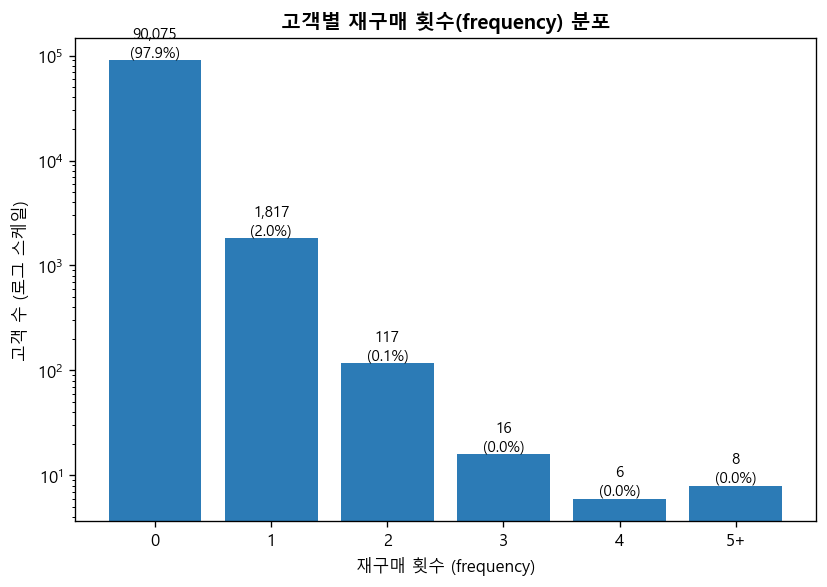

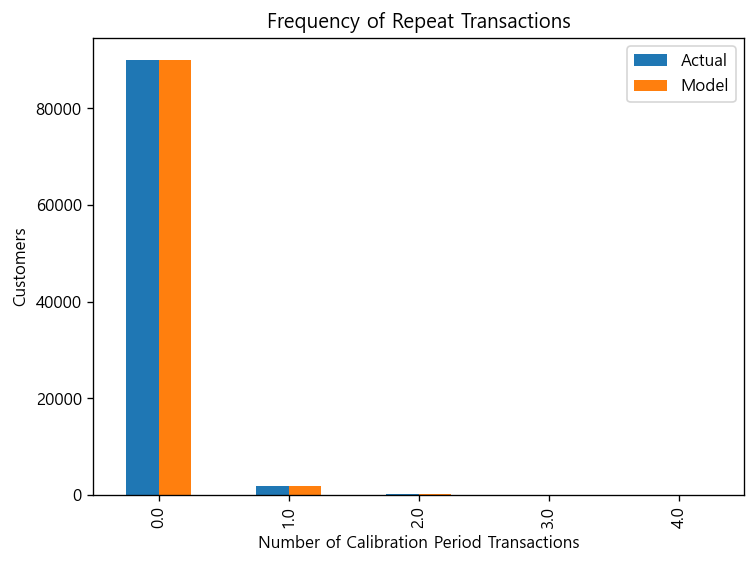

In [3]:
obs_end = orders['order_purchase_timestamp'].max()

cltv_summary = summary_data_from_transaction_data(
    orders, 'customer_unique_id', 'order_purchase_timestamp',
    monetary_value_col='payment_value_total',
    observation_period_end=obs_end, freq='D'
)

print(f'관측 종료일   : {obs_end.date()}')
print(f'고객 수       : {len(cltv_summary):,}명')
print(f'frequency > 0 : {(cltv_summary["frequency"] > 0).sum():,}명 ({(cltv_summary["frequency"] > 0).mean():.2%})')
print()
print(cltv_summary[['frequency', 'recency', 'T', 'monetary_value']].describe().round(2))

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(cltv_summary['frequency'], cltv_summary['recency'], cltv_summary['T'])
print('\n[BG/NBD 파라미터]')
print(bgf.summary)

cltv_summary['p_alive'] = bgf.conditional_probability_alive(
    cltv_summary['frequency'], cltv_summary['recency'], cltv_summary['T'])
cltv_summary['pred_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90, cltv_summary['frequency'], cltv_summary['recency'], cltv_summary['T'])

# 시각화 [1] 고객별 재구매 횟수 분포
fig, ax = plt.subplots(figsize=(7, 5))
freq_capped = cltv_summary['frequency'].clip(upper=5)
freq_counts = freq_capped.value_counts().sort_index()
freq_labels = [str(int(i)) if i < 5 else '5+' for i in freq_counts.index]
ax.bar(freq_labels, freq_counts.values, color='#2c7bb6')
for i, v in enumerate(freq_counts.values):
    ax.text(i, v, f'{v:,}\n({v/len(cltv_summary):.1%})', ha='center', va='bottom', fontsize=9)
ax.set_yscale('log')
ax.set_xlabel('재구매 횟수 (frequency)')
ax.set_ylabel('고객 수 (로그 스케일)')
ax.set_title('고객별 재구매 횟수(frequency) 분포', fontweight='bold')
plt.tight_layout()
plt.show()

# 시각화 [2] 모델 적합도: 실제 vs BG/NBD 예측 분포
plot_period_transactions(bgf, max_frequency=5)
plt.tight_layout()
plt.show()


## 3. Gamma-Gamma 모델 — 예상 평균 객단가

Gamma-Gamma 모델은 **재구매 고객(frequency > 0)**의 구매 횟수와 평균 구매금액이
서로 독립이라는 가정 하에, 고객별 "장기적으로 기대되는 평균 거래 금액"을 추정한다.

- 독립 가정 검증: `frequency`와 `monetary_value`의 상관계수가 0에 가까운지 확인한다.
- `frequency=0`인 고객(전체의 97%)에 대해서는 모집단 평균값으로 수렴한 추정치가 적용된다.


재구매 고객 수             : 1,964명
frequency-monetary 상관계수 : 0.0045  (0에 가까울수록 Gamma-Gamma 가정 충족)

[Gamma-Gamma 파라미터]
        coef  se(coef)  lower 95% bound  upper 95% bound
p  10.287426  0.302311         9.694896        10.879956
q   1.340121  0.039724         1.262262         1.417980
v   9.608477  0.308398         9.004018        10.212936

전체 모집단 평균 객단가 추정치 (frequency=0 고객에게 적용) : R$ 290.62
count    92039.00
mean       287.72
std         30.05
min         20.49
25%        290.62
50%        290.62
75%        290.62
max       2337.60
Name: exp_avg_value, dtype: float64


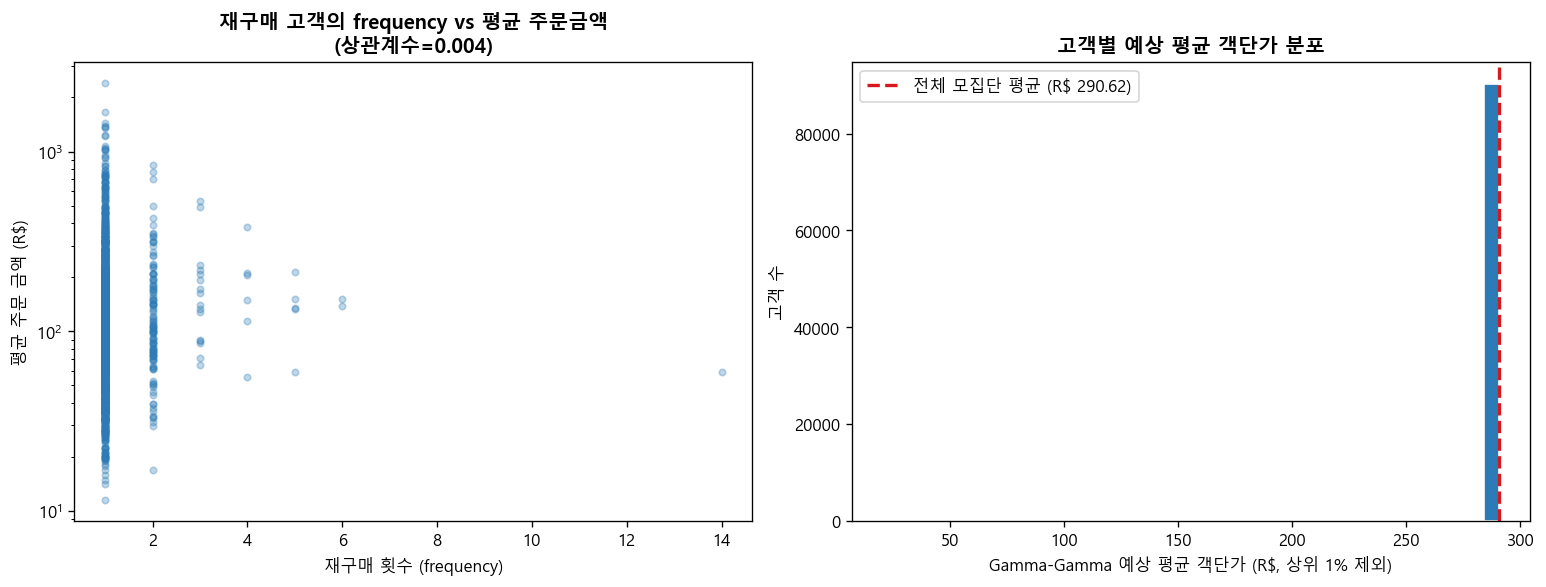

In [4]:
returning = cltv_summary[cltv_summary['frequency'] > 0]
corr = returning[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f'재구매 고객 수             : {len(returning):,}명')
print(f'frequency-monetary 상관계수 : {corr:.4f}  (0에 가까울수록 Gamma-Gamma 가정 충족)')

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(returning['frequency'], returning['monetary_value'])
print('\n[Gamma-Gamma 파라미터]')
print(ggf.summary)

cltv_summary['exp_avg_value'] = ggf.conditional_expected_average_profit(
    cltv_summary['frequency'], cltv_summary['monetary_value'])

pop_avg = cltv_summary.loc[cltv_summary['frequency'] == 0, 'exp_avg_value'].iloc[0]
print(f'\n전체 모집단 평균 객단가 추정치 (frequency=0 고객에게 적용) : R$ {pop_avg:.2f}')
print(cltv_summary['exp_avg_value'].describe().round(2))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(returning['frequency'], returning['monetary_value'], alpha=0.3, s=15, color='#2c7bb6')
ax.set_xlabel('재구매 횟수 (frequency)')
ax.set_ylabel('평균 주문 금액 (R$)')
ax.set_yscale('log')
ax.set_title(f'재구매 고객의 frequency vs 평균 주문금액\n(상관계수={corr:.3f})', fontweight='bold')

ax = axes[1]
clip_val = cltv_summary['exp_avg_value'].quantile(0.99)
ax.hist(cltv_summary['exp_avg_value'].clip(upper=clip_val), bins=40, color='#2c7bb6', edgecolor='white')
ax.axvline(pop_avg, color='#d7191c', ls='--', lw=2, label=f'전체 모집단 평균 (R$ {pop_avg:.2f})')
ax.set_xlabel('Gamma-Gamma 예상 평균 객단가 (R$, 상위 1% 제외)')
ax.set_ylabel('고객 수')
ax.set_title('고객별 예상 평균 객단가 분포', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


## 4. CLV 계산

BG/NBD(미래 구매 횟수)와 Gamma-Gamma(평균 객단가)를 결합해 **12개월 기준 고객생애가치(CLV)**를 산출한다.
할인율은 월 1% (`discount_rate=0.01`)로 가정했다.

추가로, Section 1에서 정의한 **첫 주문 배송 상태(정시/지연)** 별로 평균 CLV를 비교해
"배송 품질이 장기적인 고객 가치에도 영향을 주는지"를 함께 확인한다.


count    92039.00
mean         4.62
std          9.67
min          0.26
25%          2.87
50%          3.79
75%          5.22
max        994.37
Name: clv, dtype: float64

[분위수]
0.50    3.79
0.75    5.22
0.90    7.32
0.95    8.15
0.99    9.18
Name: clv, dtype: float64

[첫 주문 배송 상태별 12개월 CLV]
                   mean  median  count
first_order_late                      
False             4.614   3.753  84467
True              4.708   4.126   7572


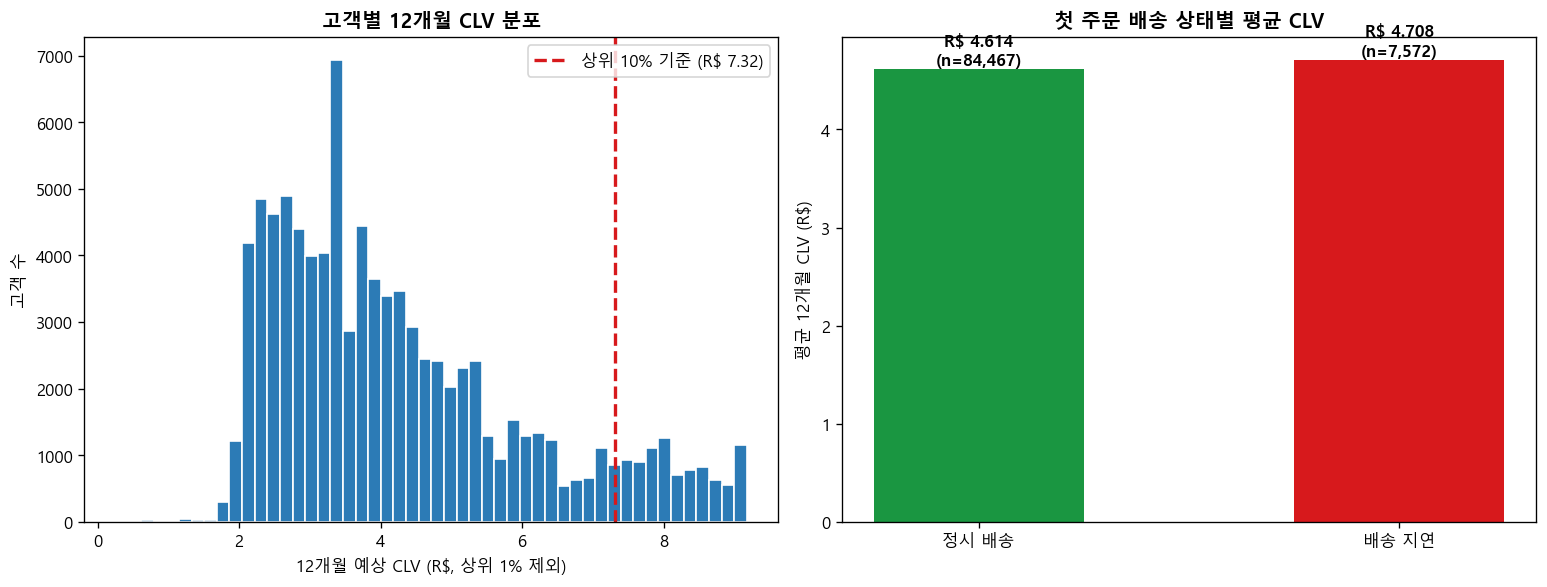

In [5]:
cltv_summary['clv'] = ggf.customer_lifetime_value(
    bgf, cltv_summary['frequency'], cltv_summary['recency'], cltv_summary['T'],
    cltv_summary['monetary_value'], time=12, freq='D', discount_rate=0.01
)

print(cltv_summary['clv'].describe().round(2))
print('\n[분위수]')
print(cltv_summary['clv'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 첫 주문 배송 상태 매핑
first_late_map = first_orders.set_index('customer_unique_id')['is_late']
cltv_summary['first_order_late'] = cltv_summary.index.map(first_late_map)

clv_by_delay = cltv_summary.groupby('first_order_late')['clv'].agg(['mean', 'median', 'count'])
print('\n[첫 주문 배송 상태별 12개월 CLV]')
print(clv_by_delay.round(3))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
clip_val = cltv_summary['clv'].quantile(0.99)
ax.hist(cltv_summary['clv'].clip(upper=clip_val), bins=50, color='#2c7bb6', edgecolor='white')
top10 = cltv_summary['clv'].quantile(0.90)
ax.axvline(top10, color='#d7191c', ls='--', lw=2, label=f'상위 10% 기준 (R$ {top10:.2f})')
ax.set_xlabel('12개월 예상 CLV (R$, 상위 1% 제외)')
ax.set_ylabel('고객 수')
ax.set_title('고객별 12개월 CLV 분포', fontweight='bold')
ax.legend()

ax = axes[1]
labels_map = {False: '정시 배송', True: '배송 지연'}
plot_data = clv_by_delay.dropna()
bars = ax.bar([labels_map[i] for i in plot_data.index], plot_data['mean'],
               color=['#1a9641', '#d7191c'], width=0.5)
for bar, val, n in zip(bars, plot_data['mean'], plot_data['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'R$ {val:.3f}\n(n={n:,.0f})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('평균 12개월 CLV (R$)')
ax.set_title('첫 주문 배송 상태별 평균 CLV', fontweight='bold')

plt.tight_layout()
plt.show()


**해석**

- 첫 주문 배송 상태별 평균 12개월 CLV는 정시 R$ 4.61 vs 지연 R$ 4.71로, 차이가 약 2% 수준에 불과하다.
- Section 1에서 확인한 재구매율 차이(정시 3.02% vs 지연 2.52%, 상대 -16.6%, p=0.014)에 비해
  CLV 차이는 훨씬 작고 통계적으로도 의미 있는 수준이라 보기 어렵다.
- 이는 CLV가 `monetary_value`(주문 금액)에도 영향을 받기 때문이다. 지연 배송 고객의 평균 재구매 빈도(`frequency`)는
  더 낮지만, Gamma-Gamma 기반 예상 객단가(`exp_avg_value`)는 두 그룹이 거의 비슷해(R$ 287.6 vs R$ 288.7) CLV 차이가 상쇄된다.
- 따라서 **"배송 지연이 고객 가치에 미치는 영향"을 입증하는 근거로는 Section 1의 재구매율 비교가 더 적합**하며,
  CLV는 이 노트북에서 본래 목적인 **VIP 세그먼트 추출**에 집중해서 활용하는 것이 타당하다.


## 5. Holdout Validation

전체 관측 기간을 **Calibration(모델 학습) 기간**과 **Holdout(검증) 기간**으로 나누어,
Calibration 기간의 구매 이력만으로 학습한 BG/NBD 모델이 Holdout 기간의 실제 구매 횟수를
얼마나 잘 예측하는지 확인한다.

- Calibration 기간: 데이터 시작 ~ 2018-02-28
- Holdout 기간: 2018-02-28 ~ 데이터 종료 (약 6개월)

**주의**: 재구매율이 낮아 Holdout 기간에 실제로 구매가 발생한 고객 수 자체가 적다.
따라서 전체 합계 기준의 오차율과 함께, Calibration 기간 구매 횟수 구간별 비교를 함께 확인해
"빈도가 높은 고객일수록 예측이 어떻게 달라지는지"를 본다.


Calibration 기간 : 530일, Holdout 기간 : 182일
고객 수          : 55,098명



Holdout 실제 총 구매수 : 674건
Holdout 예측 총 구매수 : 782.7건  (오차 +16.1%)

[Calibration 구매횟수 구간별 Holdout 실제 vs 예측 평균]
                     n    실제평균    예측평균
freq_cal_bucket                       
0회               54121  0.0112  0.0123
1회                 916  0.0480  0.0612
2회                  45  0.1778  0.6465
3회+                 16  1.0000  2.0308


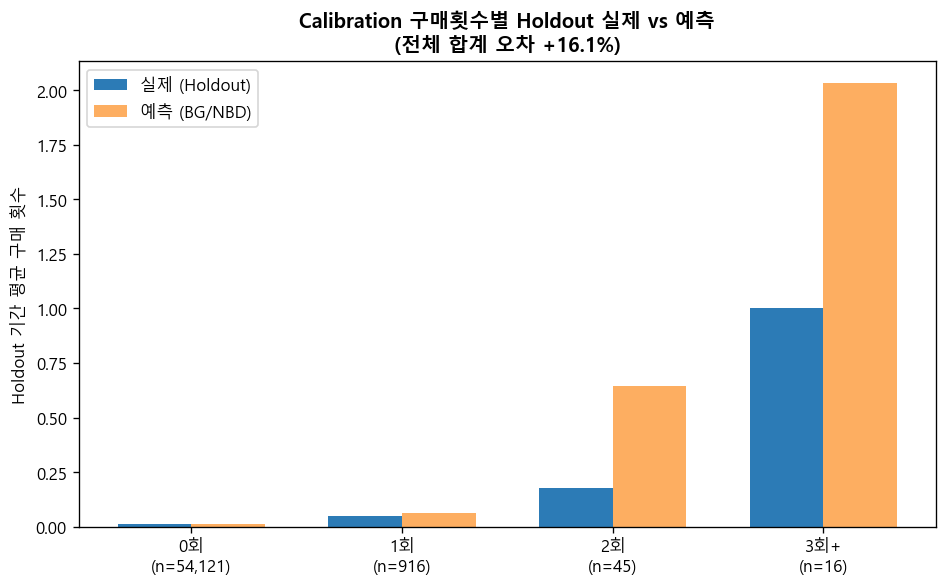

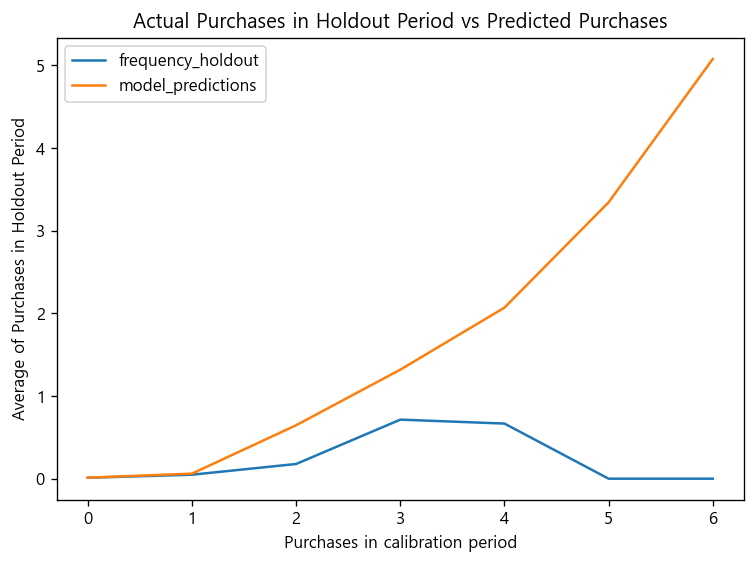

In [6]:
cal_end = pd.Timestamp('2018-02-28')
ch = calibration_and_holdout_data(
    orders, 'customer_unique_id', 'order_purchase_timestamp',
    calibration_period_end=cal_end, observation_period_end=obs_end, freq='D'
)
cal_days = (cal_end - orders['order_purchase_timestamp'].min()).days
holdout_days = (obs_end - cal_end).days
print(f'Calibration 기간 : {cal_days}일, Holdout 기간 : {holdout_days}일')
print(f'고객 수          : {len(ch):,}명')

bgf_cal = BetaGeoFitter(penalizer_coef=0.001)
bgf_cal.fit(ch['frequency_cal'], ch['recency_cal'], ch['T_cal'])
ch['pred_holdout'] = bgf_cal.predict(ch['duration_holdout'], ch['frequency_cal'], ch['recency_cal'], ch['T_cal'])

actual_total = ch['frequency_holdout'].sum()
pred_total = ch['pred_holdout'].sum()
print(f'\nHoldout 실제 총 구매수 : {actual_total:,.0f}건')
print(f'Holdout 예측 총 구매수 : {pred_total:,.1f}건  (오차 {((pred_total - actual_total) / actual_total):+.1%})')

ch['freq_cal_bucket'] = pd.cut(ch['frequency_cal'], [-1, 0, 1, 2, 100], labels=['0회', '1회', '2회', '3회+'])
bucket_cmp = ch.groupby('freq_cal_bucket', observed=True).agg(
    n=('frequency_cal', 'count'), 실제평균=('frequency_holdout', 'mean'), 예측평균=('pred_holdout', 'mean'))
print('\n[Calibration 구매횟수 구간별 Holdout 실제 vs 예측 평균]')
print(bucket_cmp.round(4))

# 시각화 [1] 구간별 실제 vs 예측
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(bucket_cmp))
w = 0.35
ax.bar(x - w/2, bucket_cmp['실제평균'], width=w, label='실제 (Holdout)', color='#2c7bb6')
ax.bar(x + w/2, bucket_cmp['예측평균'], width=w, label='예측 (BG/NBD)', color='#fdae61')
ax.set_xticks(x)
ax.set_xticklabels([f'{idx}\n(n={n:,})' for idx, n in zip(bucket_cmp.index, bucket_cmp['n'])])
ax.set_ylabel('Holdout 기간 평균 구매 횟수')
ax.set_title(f'Calibration 구매횟수별 Holdout 실제 vs 예측\n(전체 합계 오차 {((pred_total - actual_total) / actual_total):+.1%})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 시각화 [2] lifetimes 기본 보정 플롯
plot_calibration_purchases_vs_holdout_purchases(bgf_cal, ch)
plt.tight_layout()
plt.show()


**해석**

- 전체 합계 기준으로는 실제 674건 vs 예측 782.7건으로 약 **+16.1% 과대 예측**한다.
- 가장 비중이 큰 `frequency_cal=0`(54,121명, 99.0%) 구간에서는 실제 0.0112 vs 예측 0.0123으로 거의 일치한다 —
  즉 "한 번도 재구매하지 않은 대다수 고객"에 대한 예측은 안정적이다.
- 반면 `frequency_cal=2`(n=45) 구간은 실제 0.178 vs 예측 0.647로 큰 차이를 보이는데, 표본 수가 45명으로 작아
  소수의 극단치(이상 구매 패턴)에 모델이 민감하게 반응한 결과로 해석된다.
- 결론적으로 BG/NBD 모델은 **"누가 일회성 구매자로 남을지"는 잘 맞히지만, 빈번한 재구매 고객의 향후 구매 횟수**는
  표본이 적어 예측 오차가 크다. VIP 추출(Section 6)·쿠폰 타겟팅(Section 7)에서는 이 점을 감안해
  예측값의 절대 수치보다는 상대적 순위로 활용한다.


## 6. VIP 고객 추출 (상위 CLV 10%)

12개월 CLV 기준 상위 10% 고객을 VIP로 정의하고, 일반 고객 대비
- 재구매율
- 평균 CLV / 평균 주문 금액
- 지역 분포

를 비교한다. VIP 명단은 `data/vip_customers_top10pct.csv`로 저장해 리텐션 캠페인(예: 전용 혜택, 우선 고객지원) 대상 리스트로 활용할 수 있다.


VIP 기준 (상위 10% CLV) : R$ 7.32 이상
          고객수   재구매율   평균CLV  평균주문금액
is_vip                              
False   82782  0.012   3.837   1.018
True     9257  0.107  11.642  22.797

[지역별 분포 비교]
customer_region    남동부     남부    북동부     북부    중서부
is_vip                                            
False            0.681  0.145  0.096  0.019  0.059
True             0.727  0.126  0.078  0.014  0.055



전체 고객 CLV 요약 -> data/customer_clv_summary.csv (92,039명)
VIP 고객 명단      -> data/vip_customers_top10pct.csv (9,257명)


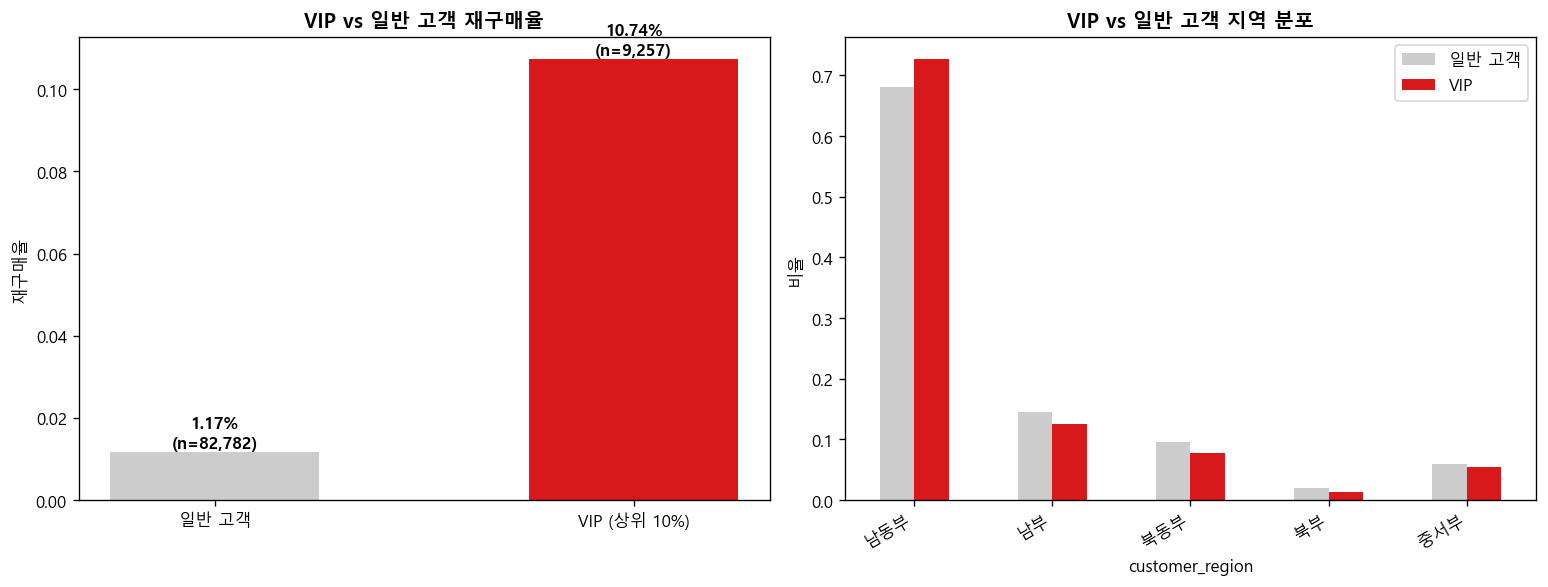

In [7]:
vip_threshold = cltv_summary['clv'].quantile(0.90)
cltv_summary['is_vip'] = cltv_summary['clv'] >= vip_threshold

region_map = orders.drop_duplicates('customer_unique_id', keep='first').set_index('customer_unique_id')['customer_region']
cltv_summary['customer_region'] = cltv_summary.index.map(region_map)
cltv_summary['is_repeater'] = cltv_summary['frequency'] > 0

vip_profile = cltv_summary.groupby('is_vip').agg(
    고객수=('clv', 'count'), 재구매율=('is_repeater', 'mean'),
    평균CLV=('clv', 'mean'), 평균주문금액=('monetary_value', 'mean'))
print(f'VIP 기준 (상위 10% CLV) : R$ {vip_threshold:.2f} 이상')
print(vip_profile.round(3))

region_dist = cltv_summary.groupby('is_vip')['customer_region'].value_counts(normalize=True).unstack().round(3)
print('\n[지역별 분포 비교]')
print(region_dist)

# CSV 저장
out_cols = ['frequency', 'recency', 'T', 'monetary_value', 'p_alive', 'pred_90d',
            'exp_avg_value', 'clv', 'customer_region', 'first_order_late', 'is_vip']
cltv_summary[out_cols].to_csv(DATA_DIR / 'customer_clv_summary.csv', encoding='utf-8-sig')
vip_customers = cltv_summary[cltv_summary['is_vip']].sort_values('clv', ascending=False)
vip_customers[out_cols].to_csv(DATA_DIR / 'vip_customers_top10pct.csv', encoding='utf-8-sig')
print(f'\n전체 고객 CLV 요약 -> data/customer_clv_summary.csv ({len(cltv_summary):,}명)')
print(f'VIP 고객 명단      -> data/vip_customers_top10pct.csv ({len(vip_customers):,}명)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(['일반 고객', 'VIP (상위 10%)'], vip_profile['재구매율'], color=['#cccccc', '#d7191c'], width=0.5)
for bar, val, n in zip(bars, vip_profile['재구매율'], vip_profile['고객수']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2%}\n(n={n:,})', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('재구매율')
ax.set_title('VIP vs 일반 고객 재구매율', fontweight='bold')

ax = axes[1]
region_dist.T.plot(kind='bar', ax=ax, color=['#cccccc', '#d7191c'])
ax.set_ylabel('비율')
ax.set_title('VIP vs 일반 고객 지역 분포', fontweight='bold')
ax.legend(['일반 고객', 'VIP'])
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


## 7. 재구매 가능성 높은 고객 — 쿠폰 전략 후보

재구매 경험이 있는 고객(`frequency >= 1`) 중에서

- `P(alive)` (현재 활성 고객일 확률)이 높고
- 향후 90일 예상 구매 횟수(`pred_90d`)도 높은

고객을 "다음 구매가 임박했고, 재구매 의향도 높은" 후보로 정의해 쿠폰/리마인드 타겟팅 후보로 추출한다.
타겟 후보 명단은 `data/coupon_target_candidates.csv`로 저장한다.


재구매 경험 고객 수 : 1,964명
쿠폰 타겟 후보 (P(alive)>=0.5, 90일 예상구매>=0.05) : 88명
-> data/coupon_target_candidates.csv 저장

                                  frequency  recency      T  \
customer_unique_id                                            
397b44d5bb99eabf54ea9c2b41ebb905        3.0    157.0  230.0   
fe81bb32c243a86b2f86fbf053fe6140        4.0    242.0  311.0   
4facc2e6fbc2bffab2fea92d2b4aa7e4        3.0    421.0  437.0   
297ec5afd18366f5ba27520cc4954151        2.0     85.0  194.0   
8d50f5eadf50201ccdcedfb9e2ac8455       14.0    428.0  437.0   
ca77025e7201e3b30c44b472ff346268        6.0    235.0  324.0   
394ac4de8f3acb14253c177f0e15bc58        4.0    236.0  250.0   
1da09dd64e235e7c2f29a4faff33535c        2.0    246.0  476.0   
dc813062e0fc23409cd255f7f53c7074        5.0    418.0  424.0   
6469f99c1f9dfae7733b25662e7f1782        5.0    282.0  344.0   

                                  days_since_last_purchase  p_alive  pred_90d  \
customer_unique_id                                   

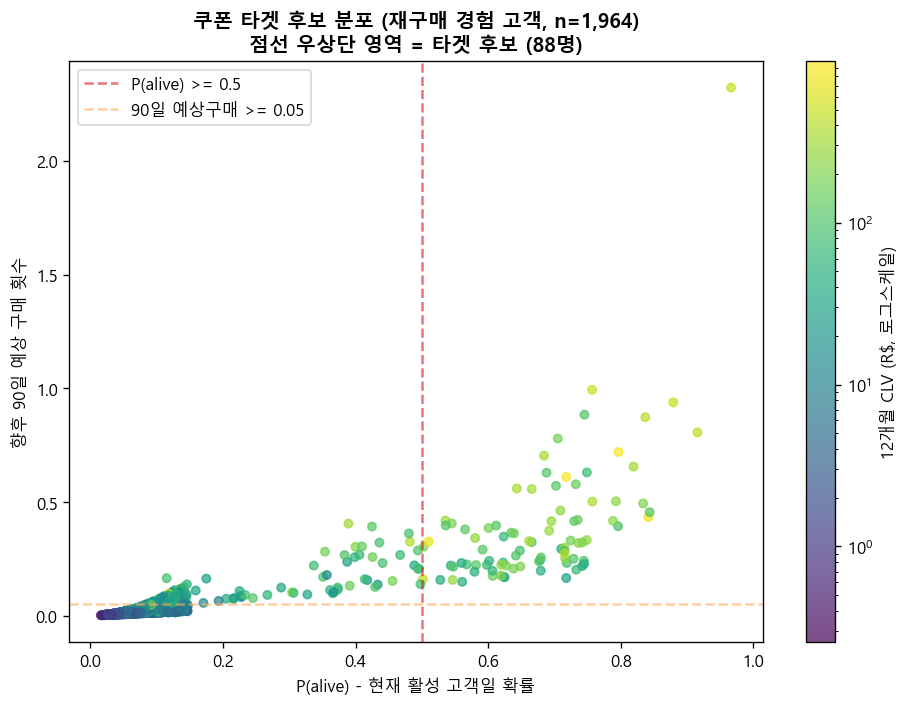

In [8]:
coupon_pool = cltv_summary[cltv_summary['frequency'] >= 1].copy()
coupon_pool['days_since_last_purchase'] = coupon_pool['T'] - coupon_pool['recency']

P_ALIVE_TH = 0.5
PRED_TH = 0.05
coupon_pool['is_target'] = (coupon_pool['p_alive'] >= P_ALIVE_TH) & (coupon_pool['pred_90d'] >= PRED_TH)

print(f'재구매 경험 고객 수 : {len(coupon_pool):,}명')
print(f'쿠폰 타겟 후보 (P(alive)>={P_ALIVE_TH}, 90일 예상구매>={PRED_TH}) : {coupon_pool["is_target"].sum():,}명')

targets = coupon_pool[coupon_pool['is_target']].sort_values('clv', ascending=False)
out_cols2 = ['frequency', 'recency', 'T', 'days_since_last_purchase', 'p_alive', 'pred_90d', 'clv', 'customer_region']
targets[out_cols2].to_csv(DATA_DIR / 'coupon_target_candidates.csv', encoding='utf-8-sig')
print(f'-> data/coupon_target_candidates.csv 저장')
print()
print(targets[out_cols2].head(10).round(3))

# 시각화
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(coupon_pool['p_alive'], coupon_pool['pred_90d'], c=coupon_pool['clv'].clip(lower=0.01),
                cmap='viridis', s=25, alpha=0.7, norm=LogNorm())
plt.colorbar(sc, ax=ax, label='12개월 CLV (R$, 로그스케일)')
ax.axvline(P_ALIVE_TH, color='#d7191c', ls='--', alpha=0.6, label=f'P(alive) >= {P_ALIVE_TH}')
ax.axhline(PRED_TH, color='#fdae61', ls='--', alpha=0.6, label=f'90일 예상구매 >= {PRED_TH}')
ax.set_xlabel('P(alive) - 현재 활성 고객일 확률')
ax.set_ylabel('향후 90일 예상 구매 횟수')
ax.set_title(f'쿠폰 타겟 후보 분포 (재구매 경험 고객, n={len(coupon_pool):,})\n점선 우상단 영역 = 타겟 후보 ({coupon_pool["is_target"].sum()}명)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 종합 정리 및 추천 순위

| 순위 | 방법 | 핵심 결과 | 활용 |
|---|---|---|---|
| 1순위 | 정시 vs 지연 배송 첫 주문 → 재구매율 비교 | 지연 그룹 재구매율이 정시 그룹 대비 통계적으로 유의하게 낮음 (-16.6%, z검정 p=0.014) | 배송 SLA 개선의 재구매 기여도를 정량적으로 제시 |
| 2순위 | BG/NBD + Gamma-Gamma → CLV / VIP 추출 | 상위 10% VIP 고객의 재구매율(10.7%)·평균 CLV(R$11.64)가 일반 고객(1.2%, R$3.84) 대비 큰 폭으로 높음, holdout 검증으로 모델 신뢰도 확인 | 상위 CLV 10% 고객 리텐션 전략 (전용 혜택, VIP 프로그램) |
| 3순위 | BG/NBD → P(alive) x 90일 예상구매 → 쿠폰 후보 | 재구매 경험 고객 1,964명 중 다음 구매 임박 고객 88명 추출 | 재구매 가능성 높은 고객 대상 쿠폰/리마인드 발송 |
| 보류 | 재구매 여부 이진분류 (로지스틱 회귀) | 미진행 (클래스 불균형 97:3) | 별도 샘플링 기법(SMOTE 등) 적용 후 재검토 권장 |
| 비권장 | 재구매 리드타임 수치화 | 미진행 (재구매 표본 2,745명으로 분포 불안정) | 재구매율 자체가 개선된 이후 표본이 늘어나면 재시도 |

**다음 액션 제안**

1. **상위 CLV 10% 고객(`data/vip_customers_top10pct.csv`, 9,257명)**: VIP 전용 혜택, 우선 고객지원 등 리텐션 프로그램 적용
2. **쿠폰 타겟 후보(`data/coupon_target_candidates.csv`, 88명)**: 다음 구매 시점이 임박한 재구매 고객에게 할인 쿠폰/리마인드 발송으로 재구매 전환 유도
3. **배송 SLA 개선**: Section 1 결과를 근거로, 첫 주문 지연을 줄이는 것이 재구매율 개선에 기여함을 정량적으로 제시 → [seller_late_score_gap_analysis.ipynb](./seller_late_score_gap_analysis.ipynb), [delay_daily_score_analysis.ipynb](./delay_daily_score_analysis.ipynb)와 연계해 "배송 품질 → 평점 → 재구매"의 종합 개선안 수립

자세한 방법론 설명과 추천 근거는 [repurchase_clv_analysis.md](./repurchase_clv_analysis.md) 참고.
